# EMAIL SPAM CLASSIFICATION

In [252]:
# required modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [253]:
url = "email.csv"
try:
    emails = pd.read_csv(url)
except FileNotFoundError:
    print("ERROR finding the file")

## data preparation

In [254]:
emails.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [255]:
print(f"shape{emails.shape}")
emails.info()

shape(5573, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [256]:
# Find any null values
emails.isnull().sum()

Category    0
Message     0
dtype: int64

In [257]:
emails = emails.dropna()

In [258]:
emails.columns

Index(['Category', 'Message'], dtype='str')

In [259]:
# Lets see the how many unique values are in Category, they should be 2
emails["Category"].nunique()

3

In [260]:
# Lets see the 3'rd unique value
emails.groupby("Category").count()

,Message
Category,
ham,4825
spam,747
"{""mode"":""full""",1


In [261]:
# Lets drop the third value
emails = emails[(emails["Category"].isin(["ham", "spam"]))]
emails.shape

(5572, 2)

In [262]:
# Remove any spaces
emails["Category"] = emails["Category"].str.strip()
emails["Category"]

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: Category, Length: 5572, dtype: str

In [263]:
# Make all of them lowercase
emails["Category"] = emails["Category"].str.lower()
emails["Category"]

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: Category, Length: 5572, dtype: str

In [264]:
# Encode
y = emails["Category"].map({"ham":0, "spam":1})
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: int64

In [265]:
x = emails["Message"]
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str

## text processing

In [266]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [267]:
vectorizer = TfidfVectorizer(stop_words="english")
x = vectorizer.fit_transform(x)

## Feature engineering

In [268]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [269]:
x_train.shape

(4457, 8440)

In [270]:
y_train.shape

(4457,)

## model training

In [271]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear'),
    "KNN": KNeighborsClassifier()
}
score = {}

In [272]:
for name, model in models.items():
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)
    acc = accuracy_score(y_test, prediction)
    report = classification_report(y_test, prediction)
    cnf = confusion_matrix(y_test, prediction)
    score[name] = {
        "accuracy":acc,
        "classification reprt":report,
        "confusion metrix":cnf
    }


## model Performance

In [273]:
for name, acc in score.items():
    print(f"{name}: {acc["accuracy"]}")

Logistic Regression: 0.95695067264574
SVM: 0.9820627802690582
KNN: 0.9103139013452914


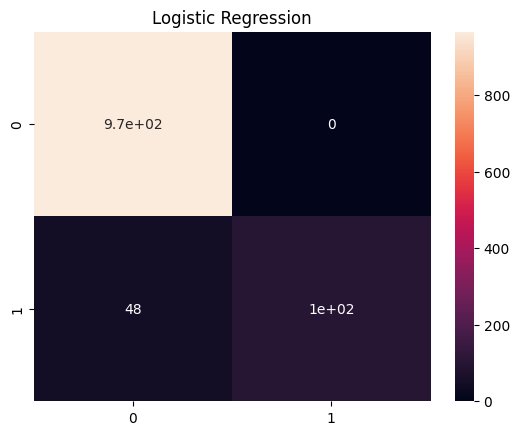

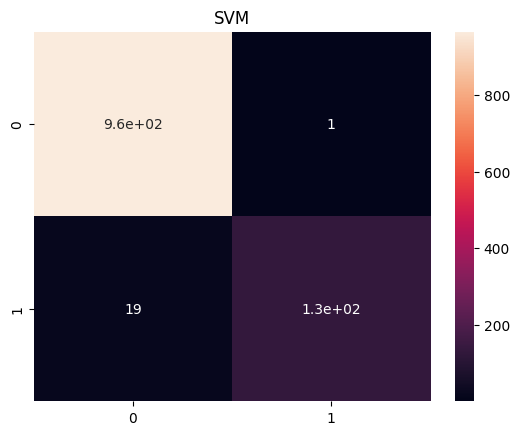

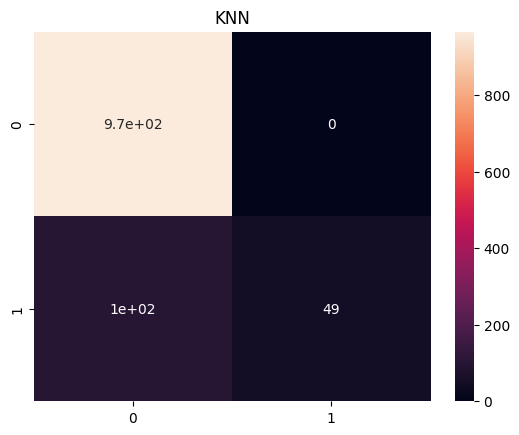

In [274]:
for name, details in score.items():
    sns.heatmap(data= details["confusion metrix"], annot=True)
    plt.title(name)
    plt.show()

## Testing the model using real emails

In [277]:
# model 1
def classify_email_Logistics_model(email):
    example_scam = vectorizer.transform([email])
    results = int(models["Logistic Regression"].predict(example_scam)[0])
    if results == 1:
        print("scam")
    else:
        print("ham")

# model 2
def classify_email_SVM_model(email):
    example_scam = vectorizer.transform([email])
    results = int(models["SVM"].predict(example_scam)[0])
    if results == 1:
        print("scam")
    else:
        print("ham")

# model 3
def classify_email_KNN_model(email):
    example_scam = vectorizer.transform([email])
    results = int(models["KNN"].predict(example_scam)[0])
    if results == 1:
        print("scam")
    else:
        print("ham")

In [278]:
# example of scam emails 
example_1 = "Congratulations! You've won a $1000 Walmart gift card! Click here to claim your prize"
example_2 = "Congrats! You’ve been selected for a remote task role. Earn daily income by rating hotels. Start today!"


exampl_emails = [example_1, example_2]
example = 1
for mail in exampl_emails:
    print(f"example_{example} model 1")
    classify_email_Logistics_model(mail)
    print("\n")
    print(f"example_{example} model 2")
    classify_email_SVM_model(mail)
    print("\n")
    print(f"example_{example} model 3")
    classify_email_KNN_model(mail)
    print("\n")
    example += 1

example_1 model 1
scam


example_1 model 2
scam


example_1 model 3
ham


example_2 model 1
ham


example_2 model 2
ham


example_2 model 3
ham




## <u>Thank you</u>